<a href="https://colab.research.google.com/github/Divyagowribabu/Data_Engineering-Assignment/blob/main/googlecolab/problem_3_scaling%26k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PROBLEM 3: Customer Segmentation
(K-Means Clustering)

 An e-commerce company wants to segment its customers into groups to:
Personalize marketing campaigns  
Recommend products  
Improve customer retention  
Since there are no labels, we use Clustering (e.g., K-Means)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv('customer_segmentation.csv')
df.head()

,CustomerID,Age,AnnualIncome,SpendingScore,VisitsPerMonth,AvgOrderValue
0,1,22,15000,39,4,200
1,2,25,18000,81,6,500
2,3,47,60000,6,2,150
3,4,52,65000,20,3,200
4,5,23,20000,77,5,450


In [ ]:

X = df.drop('CustomerID', axis=1)
X.head()


,Age,AnnualIncome,SpendingScore,VisitsPerMonth,AvgOrderValue
0,22,15000,39,4,200
1,25,18000,81,6,500
2,47,60000,6,2,150
3,52,65000,20,3,200
4,23,20000,77,5,450


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

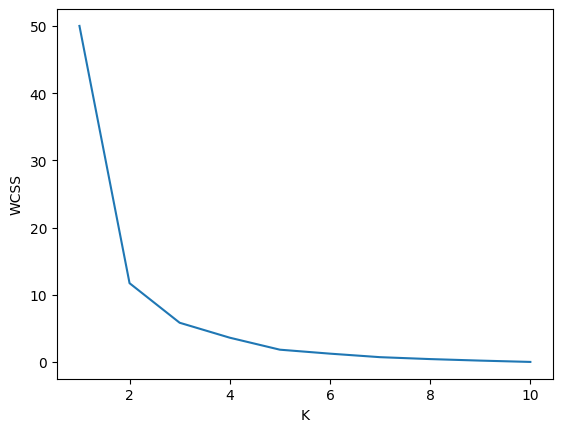

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel('K')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df

,CustomerID,Age,AnnualIncome,SpendingScore,VisitsPerMonth,AvgOrderValue,Cluster
0,1,22,15000,39,4,200,2
1,2,25,18000,81,6,500,1
2,3,47,60000,6,2,150,0
3,4,52,65000,20,3,200,0
4,5,23,20000,77,5,450,1
5,6,45,70000,15,2,180,0
6,7,33,40000,50,4,300,2
7,8,35,42000,55,5,320,2
8,9,60,80000,10,1,100,0
9,10,28,30000,70,6,400,1


In [ ]:
kmeans.cluster_centers_

array([[ 1.11237302,  1.10929679, -1.09338756, -1.08347268, -0.95135767],
       [-0.92697752, -0.95616154,  1.24694284,  1.1236013 ,  1.32025147],
       [-0.55618651, -0.52290084,  0.21090725,  0.32102894, -0.05177457]])